In [4]:
!pip install statsmodels
import pymc as pm
import arviz as az
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

print(f"PyMC Version: {pm.__version__}")
print(f"ArviZ Version: {az.__version__}")

PyMC Version: 6.1.0
ArviZ Version: 1.2.0


In [8]:
# Load the dataset
df = pd.read_csv('../BrentOilPrices.csv') # Using '../' if your CSV is in the root and notebook is in /notebooks

# Convert Date column dynamically by setting format='mixed'
df['Date'] = pd.to_datetime(df['Date'], format='mixed')
df = df.sort_values('Date').reset_index(drop=True)

# Compute daily log returns to observe volatility clustering
df['Log_Price'] = np.log(df['Price'])
df['Log_Return'] = df['Log_Price'].diff()

# Display the top rows to verify it worked!
print("First 5 rows after cleaning:")
print(df.head())

First 5 rows after cleaning:
        Date  Price  Log_Price  Log_Return
0 1987-05-20  18.63   2.924773         NaN
1 1987-05-21  18.45   2.915064   -0.009709
2 1987-05-22  18.55   2.920470    0.005405
3 1987-05-25  18.60   2.923162    0.002692
4 1987-05-26  18.63   2.924773    0.001612


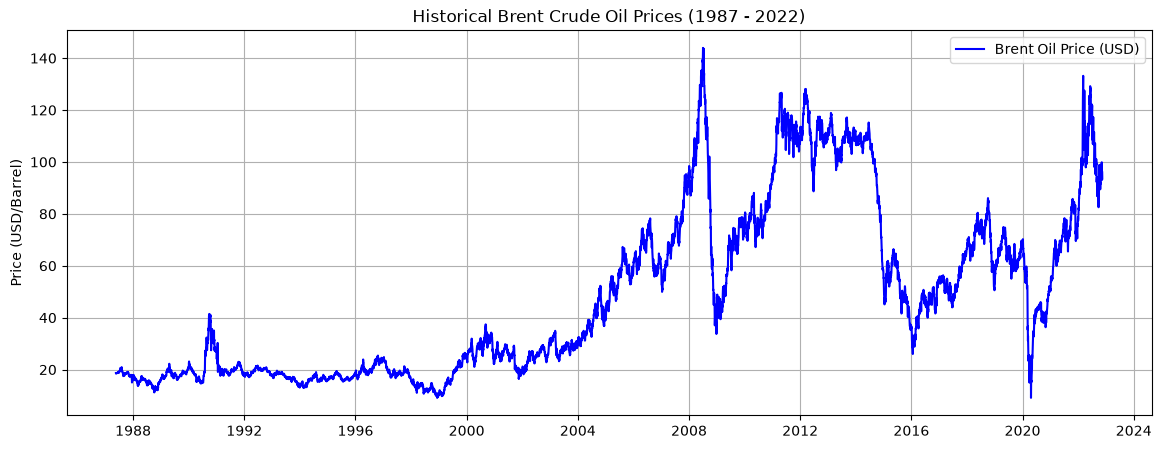

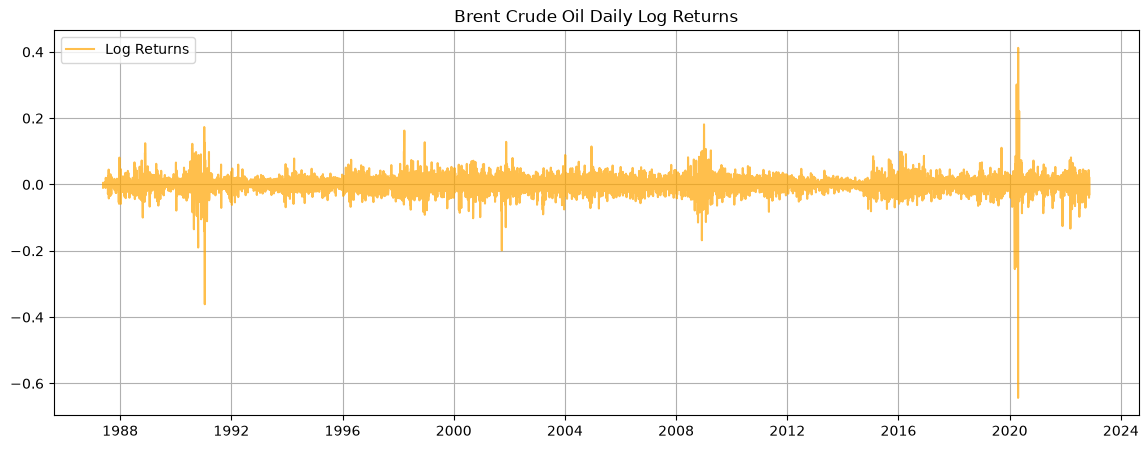

In [9]:
# Plot historical prices
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Price'], label='Brent Oil Price (USD)', color='blue')
plt.title('Historical Brent Crude Oil Prices (1987 - 2022)')
plt.ylabel('Price (USD/Barrel)')
plt.grid(True)
plt.legend()
plt.show()

# Plot daily log returns
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Log_Return'], label='Log Returns', color='orange', alpha=0.7)
plt.title('Brent Crude Oil Daily Log Returns')
plt.grid(True)
plt.legend()
plt.show()

In [10]:
# ADF test on raw prices
adf_price = adfuller(df['Price'].dropna())
print(f"Raw Price ADF p-value: {adf_price[1]:.5f}")

# ADF test on Log Returns
adf_return = adfuller(df['Log_Return'].dropna())
print(f"Log Return ADF p-value: {adf_return[1]:.5f}")

Raw Price ADF p-value: 0.28927
Log Return ADF p-value: 0.00000


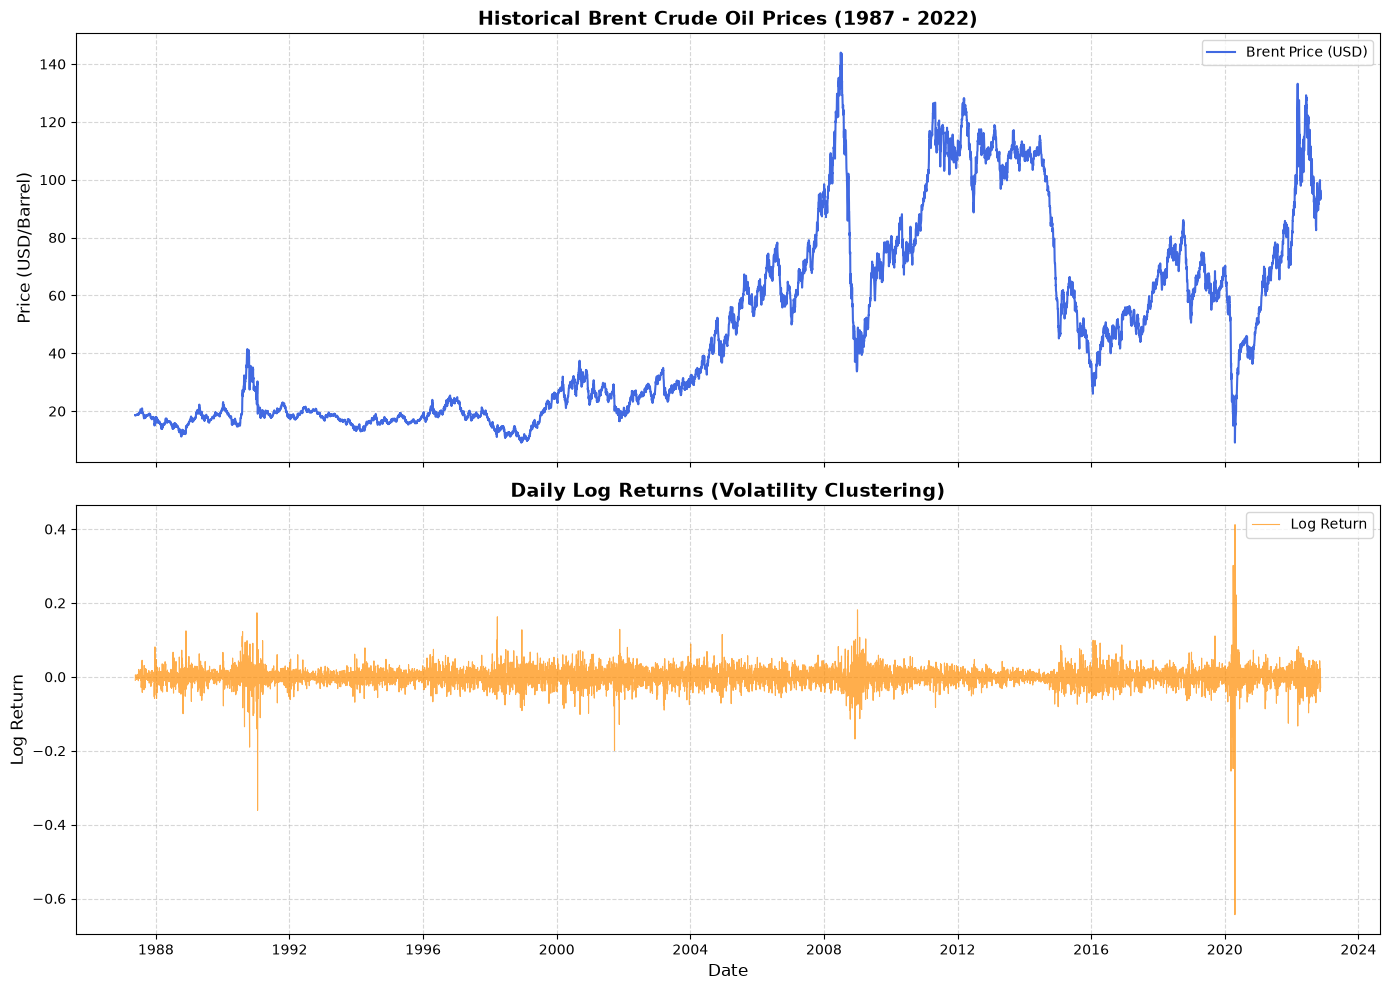

In [11]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot 1: Raw Brent Oil Price
ax1.plot(df['Date'], df['Price'], color='royalblue', linewidth=1.5, label='Brent Price (USD)')
ax1.set_title('Historical Brent Crude Oil Prices (1987 - 2022)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price (USD/Barrel)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# Plot 2: Daily Log Returns
ax2.plot(df['Date'], df['Log_Return'], color='darkorange', linewidth=0.8, alpha=0.7, label='Log Return')
ax2.set_title('Daily Log Returns (Volatility Clustering)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Log Return', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

In [12]:
# Run ADF test on raw prices
adf_price = adfuller(df['Price'].dropna())
print(f"Raw Price ADF Statistic: {adf_price[0]:.4f}")
print(f"Raw Price p-value: {adf_price[1]:.5f}")

print("-" * 40)

# Run ADF test on Log Returns
adf_return = adfuller(df['Log_Return'].dropna())
print(f"Log Return ADF Statistic: {adf_return[0]:.4f}")
print(f"Log Return p-value: {adf_return[1]:.5e}") # scientific notation for tiny numbers

Raw Price ADF Statistic: -1.9939
Raw Price p-value: 0.28927
----------------------------------------
Log Return ADF Statistic: -16.4271
Log Return p-value: 2.49858e-29


In [13]:
# 1. Slice the dataset to look specifically at the 2020 crash
df_2020 = df[(df['Date'] >= '2020-01-01') & (df['Date'] <= '2020-12-31')].reset_index(drop=True)

prices_2020 = df_2020['Price'].values
time_idx = np.arange(len(prices_2020))

print(f"Running PyMC Change Point Detection on {len(prices_2020)} trading days of 2020...")

# 2. Build the PyMC Model
with pm.Model() as change_point_model:
    # Prior for the change point (tau) - represented as an index
    tau = pm.DiscreteUniform("tau", lower=0, upper=len(prices_2020) - 1)
    
    # Priors for the mean prices before and after the change point
    mu_1 = pm.Normal("mu_1", mu=prices_2020.mean(), sigma=prices_2020.std())
    mu_2 = pm.Normal("mu_2", mu=prices_2020.mean(), sigma=prices_2020.std())
    
    # Switch function logic: assign mu_1 if index is before tau, mu_2 if after
    mu_assigned = pm.math.switch(tau > time_idx, mu_1, mu_2)
    
    # Standard deviation prior
    sigma = pm.Exponential("sigma", lam=1.0)
    
    # Likelihood
    likelihood = pm.Normal("y", mu=mu_assigned, sigma=sigma, observed=prices_2020)
    
    # Run the MCMC sampler (using 1000 draws to balance speed and accuracy)
    trace = pm.sample(draws=1000, tune=1000, return_inferencedata=True)

# 3. Print the Summary results!
print("\n--- Model Summary Results ---")
print(pm.summary(trace, var_names=["tau", "mu_1", "mu_2"]))

Running PyMC Change Point Detection on 256 trading days of 2020...


Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu_1, mu_2, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 96 seconds.
There were 25 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
C:\Users\hiwot\AppData\Local\Temp\ipykernel_16884\1584701003.py:32: DeprecationWarning: `pymc.summary` was moved out of the root namespace and will be removed in the first PyMC release of 2027. Use `pymc.stats.summary` instead.
  print(pm.summary(trace, var_names=["tau", "mu_1", "mu_2"]))



--- Model Summary Results ---
       mean     sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat mcse_mean  \
tau     223  2e+01      180      240       132        70  1.04       3.2   
mu_1  41.27   0.76       40       42      1150       840  1.00     0.023   
mu_2   48.5    2.8       44       53       183        88  1.02      0.21   

     mcse_sd  
tau      5.8  
mu_1   0.016  
mu_2    0.15  
